# Earthquakes Analysis with Elasticsearch

Dans ce notebook, nous allons interroger les données de tremblements de terre et de blasts
ingérées dans Elasticsearch par le conteneur `ingest-init`.

Indices utilisés :
- `ncedc-earthquakes-earthquake`
- `ncedc-earthquakes-blast`

Assurez-vous que :
- `docker compose up -d` a été lancé
- le job d'ingestion a terminé (voir logs du conteneur `ingest-init`)

In [1]:
!pip install "elasticsearch>=8.0.0,<10.0.0"

In [2]:
from elasticsearch import Elasticsearch

ES_HOST = "http://elasticsearch:9200"
ES_USER = "elastic"
ES_PASSWORD = "111"  # ou récupérer via variable d'env si tu préfères

es = Elasticsearch(
    ES_HOST,
    basic_auth=(ES_USER, ES_PASSWORD),
)

if es.ping():
    print("Connected to Elasticsearch!")
else:
    raise RuntimeError("Could not connect to Elasticsearch")


Connected to Elasticsearch!


In [ ]:
indices = ["ncedc-earthquakes-earthquake", "ncedc-earthquakes-blast"]

for index in indices:
    if not es.indices.exists(index=index):
        es.indices.create(index=index)
        print(f"Created empty index: {index}")
    else:
        print(f"Index already exists: {index}")

Index already exists: ncedc-earthquakes-earthquake
Index already exists: ncedc-earthquakes-blast


In [11]:
for index in indices:
    if es.indices.exists(index=index):
        count = es.count(index=index)["count"]
        print(f"{index}: {count} documents")
    else:
        print(f"{index} does NOT exist")

ncedc-earthquakes-earthquake: 0 documents
ncedc-earthquakes-blast: 0 documents


In [12]:
import os
print(os.getcwd())
print(os.listdir())


/home/jovyan
['.profile', '.bash_logout', '.bashrc', '.local', '.ipython', '.cache', 'work', '.config', '.jupyter', '.wget-hsts', '.mamba']


Si il fonctionne pas il faut lancer la commande 

docker cp ncedc-earthquakes-dataset jupyter:/home/jovyan/work/


In [13]:
from pathlib import Path
import os

print("CWD:", os.getcwd())
print("Contenu de work:", os.listdir("/home/jovyan/work"))

SOURCE_DIR = Path("/home/jovyan/work/ncedc-earthquakes-dataset")
print("Exists:", SOURCE_DIR.exists())
print("Files:", list(SOURCE_DIR.glob("*")))

CWD: /home/jovyan
Contenu de work: ['ncedc-earthquakes-dataset']
Exists: True
Files: [PosixPath('/home/jovyan/work/ncedc-earthquakes-dataset/ncedc-earthquakes-dashboards.json'), PosixPath('/home/jovyan/work/ncedc-earthquakes-dataset/ncedc-earthquakes-dashboards.ndjson'), PosixPath('/home/jovyan/work/ncedc-earthquakes-dataset/Earthquakes_Analysis.ipynb'), PosixPath('/home/jovyan/work/ncedc-earthquakes-dataset/earthquakes.txt'), PosixPath('/home/jovyan/work/ncedc-earthquakes-dataset/ncedc-earthquakes-pipeline.json'), PosixPath('/home/jovyan/work/ncedc-earthquakes-dataset/ncedc-earthquakes-template.json'), PosixPath('/home/jovyan/work/ncedc-earthquakes-dataset/blasts.txt')]


In [14]:
import json
from pathlib import Path
import requests

ES_URL = "http://elasticsearch:9200"
AUTH = ("elastic", "111")
SOURCE_DIR = Path("/home/jovyan/work/ncedc-earthquakes-dataset")  # adapte le chemin au volume monté

def bulk_ingest(file_path: Path, index_name: str, event_type: str, limit: int | None = 5000):
    buffer = []
    count = 0

    def flush():
        nonlocal buffer
        if not buffer:
            return
        payload = "\n".join(buffer) + "\n"
        r = requests.post(
            f"{ES_URL}/_bulk?pipeline=ncedc-earthquakes",
            data=payload.encode("utf-8"),
            headers={"Content-Type": "application/x-ndjson"},
            auth=AUTH,
            timeout=60,
        )
        r.raise_for_status()
        resp = r.json()
        if resp.get("errors"):
            raise RuntimeError("Bulk ingest error")
        buffer = []

    with file_path.open("r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue
            buffer.append(json.dumps({"index": {"_index": index_name}}))
            buffer.append(json.dumps({"message": line, "type": event_type}))
            count += 1
            if count % 1000 == 0:
                flush()
            if limit is not None and count >= limit:
                break

    flush()
    print(f"Ingested {count} lines into {index_name}")

bulk_ingest(SOURCE_DIR / "earthquakes.txt", "ncedc-earthquakes-earthquake", "earthquake")
bulk_ingest(SOURCE_DIR / "blasts.txt", "ncedc-earthquakes-blast", "blast")

Ingested 5000 lines into ncedc-earthquakes-earthquake
Ingested 222 lines into ncedc-earthquakes-blast


In [15]:
resp = es.search(
    index="ncedc-earthquakes-earthquake",
    size=5,
    query={"match_all": {}},
)
for hit in resp["hits"]["hits"]:
    print(hit["_source"])


{'dmin': '', 'source': 'tul', 'message': '2016/01/08 02:58:52.80,36.4723,-98.7525,8.49,2.60,ML,,116,,0.74,tul,201601082013', 'type': 'earthquake', 'magType': 'ML', 'nst': '', 'mag': '2.60', 'depth': '8.49', 'event_id': '201601082013', '@timestamp': '2016-01-08T02:58:52.800Z', 'gap': '116', 'rms': '0.74', 'location': '36.4723, -98.7525'}
{'dmin': '1', 'source': 'us', 'message': '2016/01/08 03:00:54.33,-30.5538,-71.6456,27.10,4.20,Mb,,159,1,1.09,us,201601082014', 'type': 'earthquake', 'magType': 'Mb', 'nst': '', 'mag': '4.20', 'depth': '27.10', 'event_id': '201601082014', '@timestamp': '2016-01-08T03:00:54.330Z', 'gap': '159', 'rms': '1.09', 'location': '-30.5538, -71.6456'}
{'dmin': '', 'source': 'tul', 'message': '2016/01/08 03:03:31.90,36.5234,-98.6936,6.52,2.60,ML,,116,,0.59,tul,201601082015', 'type': 'earthquake', 'magType': 'ML', 'nst': '', 'mag': '2.60', 'depth': '6.52', 'event_id': '201601082015', '@timestamp': '2016-01-08T03:03:31.900Z', 'gap': '116', 'rms': '0.59', 'location': 

In [16]:
body = {
    "size": 0,
    "aggs": {
        "mag_hist": {
            "histogram": {
                "field": "mag",
                "interval": 0.5,
                "min_doc_count": 1,
            }
        }
    },
}

resp_eq = es.search(index="ncedc-earthquakes-earthquake", body=body)
buckets = resp_eq["aggregations"]["mag_hist"]["buckets"]
buckets[:5]

[{'key': 1.0, 'doc_count': 1354},
 {'key': 1.5, 'doc_count': 645},
 {'key': 2.0, 'doc_count': 278},
 {'key': 2.5, 'doc_count': 778},
 {'key': 3.0, 'doc_count': 370}]

## Distribution des magnitudes

On commence par un histogramme de la magnitude (`mag`) pour les tremblements de terre.
Chaque bucket représente un intervalle de 0.5 de magnitude.

In [17]:
def mag_hist(index_name: str):
    body = {
        "size": 0,
        "aggs": {
            "mag_hist": {
                "histogram": {
                    "field": "mag",
                    "interval": 0.5,
                    "min_doc_count": 1,
                }
            }
        },
    }
    resp = es.search(index=index_name, body=body)
    return resp["aggregations"]["mag_hist"]["buckets"]

eq_buckets = mag_hist("ncedc-earthquakes-earthquake")
blast_buckets = mag_hist("ncedc-earthquakes-blast")


In [18]:
body = {
    "size": 0,
    "aggs": {
        "per_month": {
            "date_histogram": {
                "field": "@timestamp",
                "calendar_interval": "1M",
                "min_doc_count": 1,
            }
        }
    },
}

resp_eq_time = es.search(index="ncedc-earthquakes-earthquake", body=body)
time_buckets = resp_eq_time["aggregations"]["per_month"]["buckets"]
time_buckets[:5]


[{'key_as_string': '2016-01-01T00:00:00.000Z',
  'key': 1451606400000,
  'doc_count': 3902},
 {'key_as_string': '2016-02-01T00:00:00.000Z',
  'key': 1454284800000,
  'doc_count': 1097}]

## Évolution du nombre de tremblements de terre dans le temps

On regroupe les événements par mois en utilisant un `date_histogram` sur `@timestamp`.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def buckets_to_df(buckets, label):
    return pd.DataFrame(
        {
            "mag": [b["key"] for b in buckets],
            "count": [b["doc_count"] for b in buckets],
            "type": label,
        }
    )

df_eq = buckets_to_df(eq_buckets, "earthquake")
df_blast = buckets_to_df(blast_buckets, "blast")

df_mag = pd.concat([df_eq, df_blast], ignore_index=True)
df_mag.head()


,mag,count,type
0,1.0,1354,earthquake
1,1.5,645,earthquake
2,2.0,278,earthquake
3,2.5,778,earthquake
4,3.0,370,earthquake


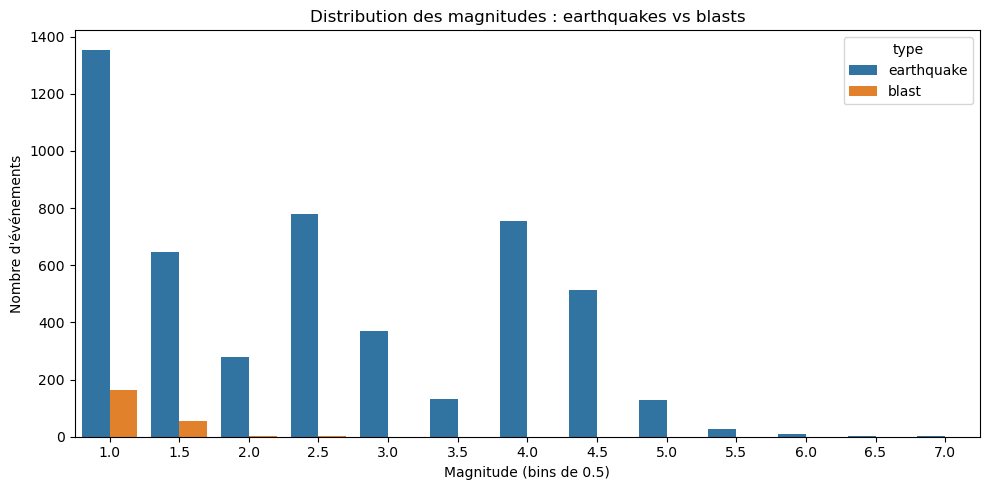

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_mag,
    x="mag",
    y="count",
    hue="type",
)
plt.title("Distribution des magnitudes : earthquakes vs blasts")
plt.xlabel("Magnitude (bins de 0.5)")
plt.ylabel("Nombre d'événements")
plt.tight_layout()
plt.show()


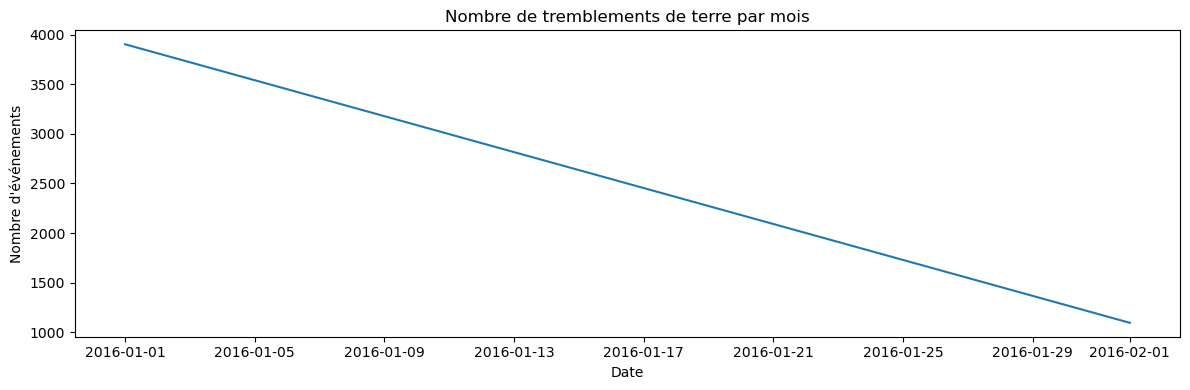

In [21]:
df_time = pd.DataFrame(
    {
        "date": [pd.to_datetime(b["key_as_string"]) for b in time_buckets],
        "count": [b["doc_count"] for b in time_buckets],
    }
)

plt.figure(figsize=(12, 4))
plt.plot(df_time["date"], df_time["count"])
plt.title("Nombre de tremblements de terre par mois")
plt.xlabel("Date")
plt.ylabel("Nombre d'événements")
plt.tight_layout()
plt.show()


## Aller plus loin dans Kibana

Pour créer des visualisations plus avancées (cartes, dashboards), suivez le guide
**Earthquakes Ingestion Guide** (`data_visualization.md`) dans le dépôt.

Les mêmes index sont utilisés :
- `ncedc-earthquakes-earthquake`
- `ncedc-earthquakes-blast`
